# EDA — Brain Tumor MRI Dataset

Proyecto final — Tecnicatura en Ciencias de Datos. Bimestre 1 (local).

**Objetivo.** Antes de tocar una línea de modelado, quiero entender el dataset y salir
de este notebook con evidencia para tres decisiones que hoy están en `TBD`:

| Pregunta del EDA | Decisión que destraba |
|---|---|
| ¿Está balanceado por clase? | Si hace falta pesar la loss o balancear el sampling |
| ¿Qué resoluciones tienen las imágenes? | El valor de `data.image_size` en `config/config.yaml` (hoy 150 sin justificar) |
| ¿Cuánto fondo negro y qué contraste tienen? | Hasta dónde puede llegar el augmentation sin distorsionar features clínicas |
| ¿Hay imágenes duplicadas? | Si hay riesgo de fuga de datos entre train y test |

**Nota sobre el framework.** No importo PyTorch ni TensorFlow a propósito: esa decisión
sigue abierta, y el EDA es justamente la parte del proyecto que no depende de ella.

---
## 0. Setup

> **Kernel local.** Corro este notebook con el intérprete del venv del proyecto
> (`.venv/`), no en una VM remota. Veo el código de `src/` directo desde disco: no hace
> falta pushear a GitHub para que un cambio se refleje acá.

In [16]:
# Raíz del proyecto: la carpeta que contiene notebooks/. La usa la celda de
# abajo para el sys.path, así `from src.data import eda` resuelve siempre,
# sin importar desde qué directorio se lanzó Jupyter.
from pathlib import Path

REPO_DIR = str(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd())
print("Raíz del proyecto:", REPO_DIR)

Raíz del proyecto: c:\Users\Win10\OneDrive\Desktop\Franco\Estudio\Ciencias de datos\Proyecto Final\mri-tumor-classifier\mri-tumor-classifier


In [17]:
%load_ext autoreload
%autoreload 2
# Recarga automática de src/ en cada celda: al tocar eda.py (u otro módulo de
# src/) no hace falta reiniciar el kernel para que el notebook vea el cambio.

import sys

if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

import matplotlib.pyplot as plt
import pandas as pd

from src.data import eda

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.dpi"] = 110

print("Helpers disponibles:", [n for n in dir(eda) if not n.startswith("_")])

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Helpers disponibles: ['CLASES', 'ETIQUETAS', 'EXTENSIONES', 'Image', 'Path', 'detectar_duplicados', 'estadisticas_intensidad', 'graficar_distribucion_clases', 'graficar_intensidades', 'graficar_muestras', 'graficar_resoluciones', 'hashlib', 'inspeccionar_metadatos', 'listar_imagenes', 'np', 'pd', 'plt', 'recomendar_image_size', 'resumen_por_clase']


### 0.1 Credenciales de Kaggle

El dataset se baja con la API de Kaggle, que necesita un token. Lo tomo del `.env` en la
raíz del proyecto (`KAGGLE_API_TOKEN`), que **no versiono** (está en `.gitignore`). Si
todavía no lo completaste:

1. Entrá a <https://www.kaggle.com/settings> → sección **API** → *Create New Token*.
2. Pegá el token en `KAGGLE_API_TOKEN` en el archivo `.env` de la raíz del proyecto.

In [18]:
from dotenv import load_dotenv

# Carga KAGGLE_API_TOKEN del .env como variable de entorno.
# kagglehub lo busca ahí automáticamente, sin pedir login interactivo.
load_dotenv(Path(REPO_DIR) / ".env")

import kagglehub

try:
    kagglehub.whoami()
    print("Ya estás autenticado en Kaggle.")
except Exception as e:
    raise RuntimeError(
        "No se pudo autenticar con Kaggle. Revisá que KAGGLE_API_TOKEN "
        "esté completo en el .env de la raíz del proyecto."
    ) from e

Kaggle credentials successfully validated.
Ya estás autenticado en Kaggle.


In [19]:
# Descarga (y cachea) el dataset localmente. ~150 MB, tarda menos de un minuto
# la primera vez; después kagglehub reusa el cache.
ruta_dataset = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")
print("Dataset en:", ruta_dataset)

# Veamos cómo quedó organizado en disco.
import os

for raiz, dirs, archivos in os.walk(ruta_dataset):
    nivel = raiz.replace(str(ruta_dataset), "").count(os.sep)
    if nivel <= 2:
        print("  " * nivel + os.path.basename(raiz) + f"/  ({len(archivos)} archivos)")

Dataset en: C:\Users\Win10\.cache\kagglehub\datasets\masoudnickparvar\brain-tumor-mri-dataset\versions\2
2/  (0 archivos)
  Testing/  (0 archivos)
    glioma/  (400 archivos)
    meningioma/  (400 archivos)
    notumor/  (400 archivos)
    pituitary/  (400 archivos)
  Training/  (0 archivos)
    glioma/  (1400 archivos)
    meningioma/  (1400 archivos)
    notumor/  (1400 archivos)
    pituitary/  (1400 archivos)


---
## 1. Inventario: qué hay realmente en el dataset

`eda.listar_imagenes()` recorre el árbol de carpetas y arma un DataFrame con una fila por
imagen. La clase sale del nombre de la carpeta contenedora, y `split_origen` guarda si la
imagen venía en `Training/` o en `Testing/` del dataset original.

Ojo con ese `split_origen`: es el split **que trae Kaggle**, no el mío. Más adelante
rehago la división de forma estratificada y con semilla fija en
`preprocessing.split_dataset()`, así que por ahora es solo información de contexto.

In [20]:
df = eda.listar_imagenes(ruta_dataset)

print(f"Total de imágenes encontradas: {len(df):,}")
print(f"Clases: {sorted(df['clase'].unique())}")
print(f"Carpetas de origen: {sorted(df['split_origen'].dropna().unique())}")
df.head()

Total de imágenes encontradas: 7,200
Clases: ['glioma', 'meningioma', 'notumor', 'pituitary']
Carpetas de origen: ['testing', 'training']


,path,archivo,clase,split_origen,peso_kb
0,C:\Users\Win10\.cache\kagglehub\datasets\masou...,Te-gl_1.jpg,glioma,testing,29.6
1,C:\Users\Win10\.cache\kagglehub\datasets\masou...,Te-gl_10.jpg,glioma,testing,16.1
2,C:\Users\Win10\.cache\kagglehub\datasets\masou...,Te-gl_100.jpg,glioma,testing,16.9
3,C:\Users\Win10\.cache\kagglehub\datasets\masou...,Te-gl_101.jpg,glioma,testing,24.8
4,C:\Users\Win10\.cache\kagglehub\datasets\masou...,Te-gl_102.jpg,glioma,testing,24.5


**Chequeo:** la página de Kaggle del dataset dice 7.200 imágenes, así que el número de
arriba coincide. (La documentación del proyecto tenía escrito 7.023 —la cifra que citan
varios papers/kernels sobre este dataset combinado—, pero no es lo que efectivamente
publica Kaggle hoy; ya corregí esto en `README.md` y `CLAUDE.md`.)

---
## 2. Distribución por clase

La pregunta concreta: ¿hay una clase tan sub-representada que el modelo la vaya a ignorar?

Me importa más de lo habitual acá. La métrica prioritaria del proyecto es **recall**, no
accuracy: un modelo que nunca predice la clase minoritaria puede tener accuracy alta y
recall desastroso justo en la clase que menos quiero fallar.

In [21]:
resumen = eda.resumen_por_clase(df)
resumen

,imagenes,porcentaje,peso_kb_medio
Glioma,1800,25.0,19.7
Meningioma,1800,25.0,21.9
Pituitario,1800,25.0,29.9
Sin tumor,1800,25.0,19.6


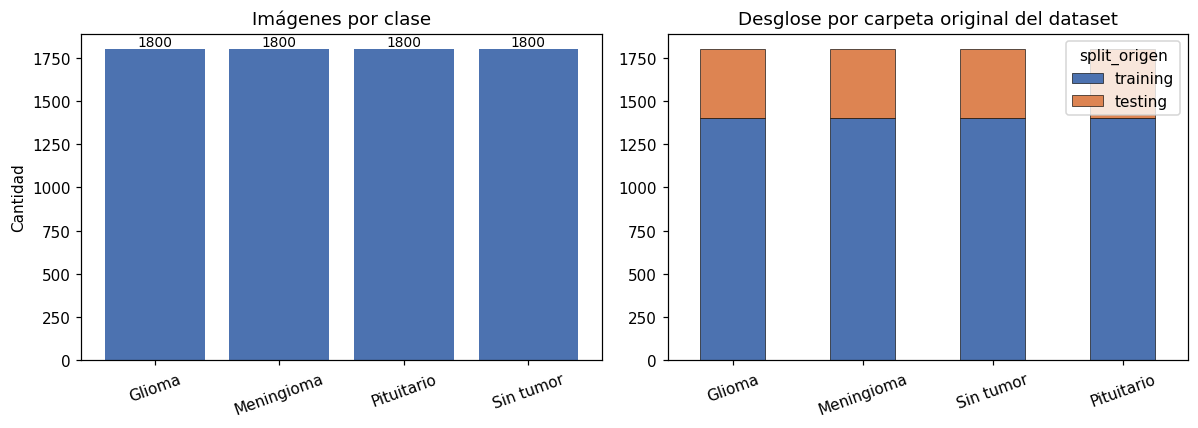

In [22]:
fig = eda.graficar_distribucion_clases(df)
plt.show()

**Conclusión:**

- Clase más frecuente: ninguna — las 4 empatan en 1.800 imágenes (25% c/u).
- Clase menos frecuente: ídem, empate perfecto.
- Ratio max/min: 1.0 — dataset perfectamente balanceado.
- ¿Hace falta balancear? No. No necesito class weights ni sampling especial.

---
## 3. Resoluciones — el insumo para `image_size`

Acá resuelvo el TBD más concreto del `config.yaml`. Hoy dice `image_size: 150` y ese
valor no salió de ningún lado.

Lo que importa no es el tamaño promedio, sino **cuántas imágenes habría que agrandar**
para llegar al tamaño elegido. Hacer upscaling de una MRI inventa detalle que no existe
en el estudio original, y en un contexto clínico eso es exactamente lo que quiero evitar.

In [23]:
# Rápido incluso sobre 7.200 imágenes: PIL lee el header sin decodificar los píxeles.
df_meta = eda.inspeccionar_metadatos(df)

print("Imágenes que no se pudieron abrir:", (df_meta["modo"] == "ERROR").sum())
print("\nModos de color presentes:")
print(df_meta["modo"].value_counts())
print("\nResoluciones más frecuentes:")
print(df_meta.groupby(["ancho", "alto"]).size().sort_values(ascending=False).head(10))

df_meta[["ancho", "alto", "lado_menor", "aspect_ratio"]].describe().round(2)

Imágenes que no se pudieron abrir: 0

Modos de color presentes:
modo
RGB     4129
L       3067
RGBA       3
P          1
Name: count, dtype: int64

Resoluciones más frecuentes:
ancho  alto
512    512     5014
225    225      338
630    630       90
201    251       57
228    221       51
232    217       50
236    236       48
442    442       48
150    198       44
200    252       43
dtype: int64


,ancho,alto,lado_menor,aspect_ratio
count,7200.00,7200.0,7200.00,7200.00
mean,453.30,456.9,450.27,0.99
std,130.05,124.4,129.82,0.09
min,150.00,167.0,150.00,0.64
25%,442.00,449.0,442.00,1.00
50%,512.00,512.0,512.00,1.00
75%,512.00,512.0,512.00,1.00
max,1375.00,1446.0,1375.00,1.79


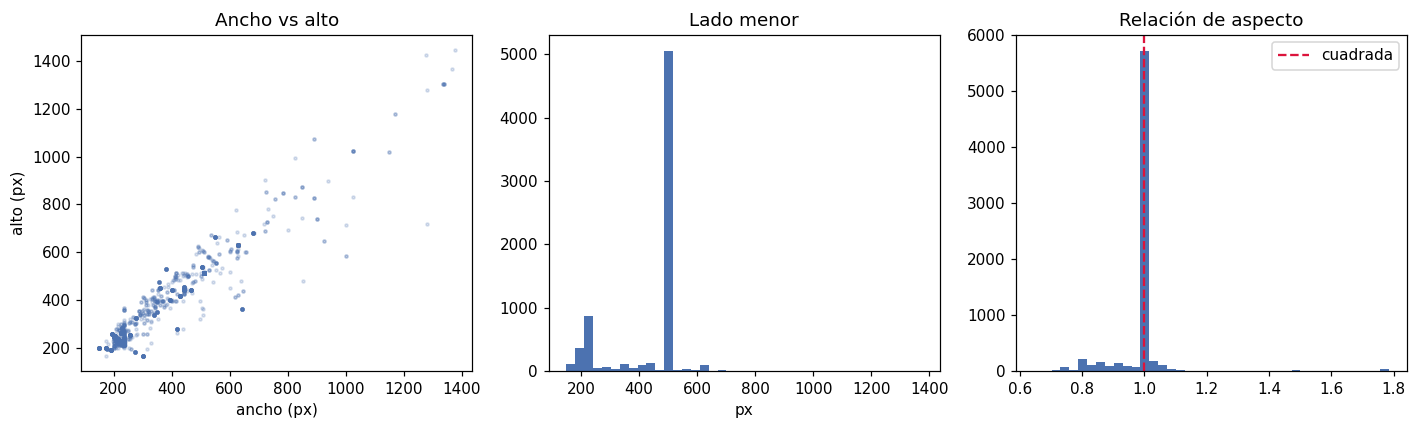

In [24]:
fig = eda.graficar_resoluciones(df_meta)
plt.show()

In [25]:
# Para cada candidato: qué porcentaje del dataset habría que agrandar vs achicar.
eda.recomendar_image_size(df_meta, candidatos=(150, 224, 256))

,pct_upscaling,pct_sin_cambio,pct_downscaling,factor_medio
candidato,,,,
150,0.0,0.6,99.4,0.38
224,11.3,0.1,88.6,0.57
256,18.8,0.5,80.7,0.65


**Conclusión:**

- Resolución dominante: 512×512 (5.014 de 7.200 imágenes, ~70%). Rango: desde 150px hasta
  1.446px de lado.
- ¿Son todas cuadradas? La mayoría (aspect ratio medio 0.99, mediana en 1.0), pero no
  todas — hay algo de variación (min 0.64, max 1.79).
- ¿Vienen en escala de grises (`L`) o en RGB? Mezcla: 4.129 en RGB, 3.067 en `L`. No es un
  problema para EfficientNet/MobileNet (esperan 3 canales) — al preprocesar, convierto
  las `L` a RGB duplicando el canal.
- **Valor elegido para `image_size`: 224×224.** Con 150, el 99.4% de las imágenes se
  achican sin necesidad de upscaling, pero eso tira más del 90% de la resolución real de
  la mayoría del dataset (que es 512×512) sin ninguna ganancia a cambio. Elijo 224 porque
  coincide con la resolución preentrenada estándar de EfficientNet-B0/MobileNetV2 sobre
  ImageNet, aprovechando mejor el backbone congelado, a costa de upscaling en el 11.3% de
  las imágenes más chicas (256 subía ese costo a 18.8% por un beneficio marginal).

Ya actualicé `config/config.yaml` y `docs/model_card.md`.

---
## 4. Muestras visuales

Mirar las imágenes no es decoración. Es lo que me deja ver la orientación de los cortes
(axial, coronal, sagital), el contraste, cuánto fondo negro hay alrededor del cerebro y
si hay artefactos o texto quemado en la imagen.

Todo eso condiciona el augmentation: si los cortes vienen siempre en la misma orientación,
una rotación grande genera imágenes que no existen en la práctica clínica.

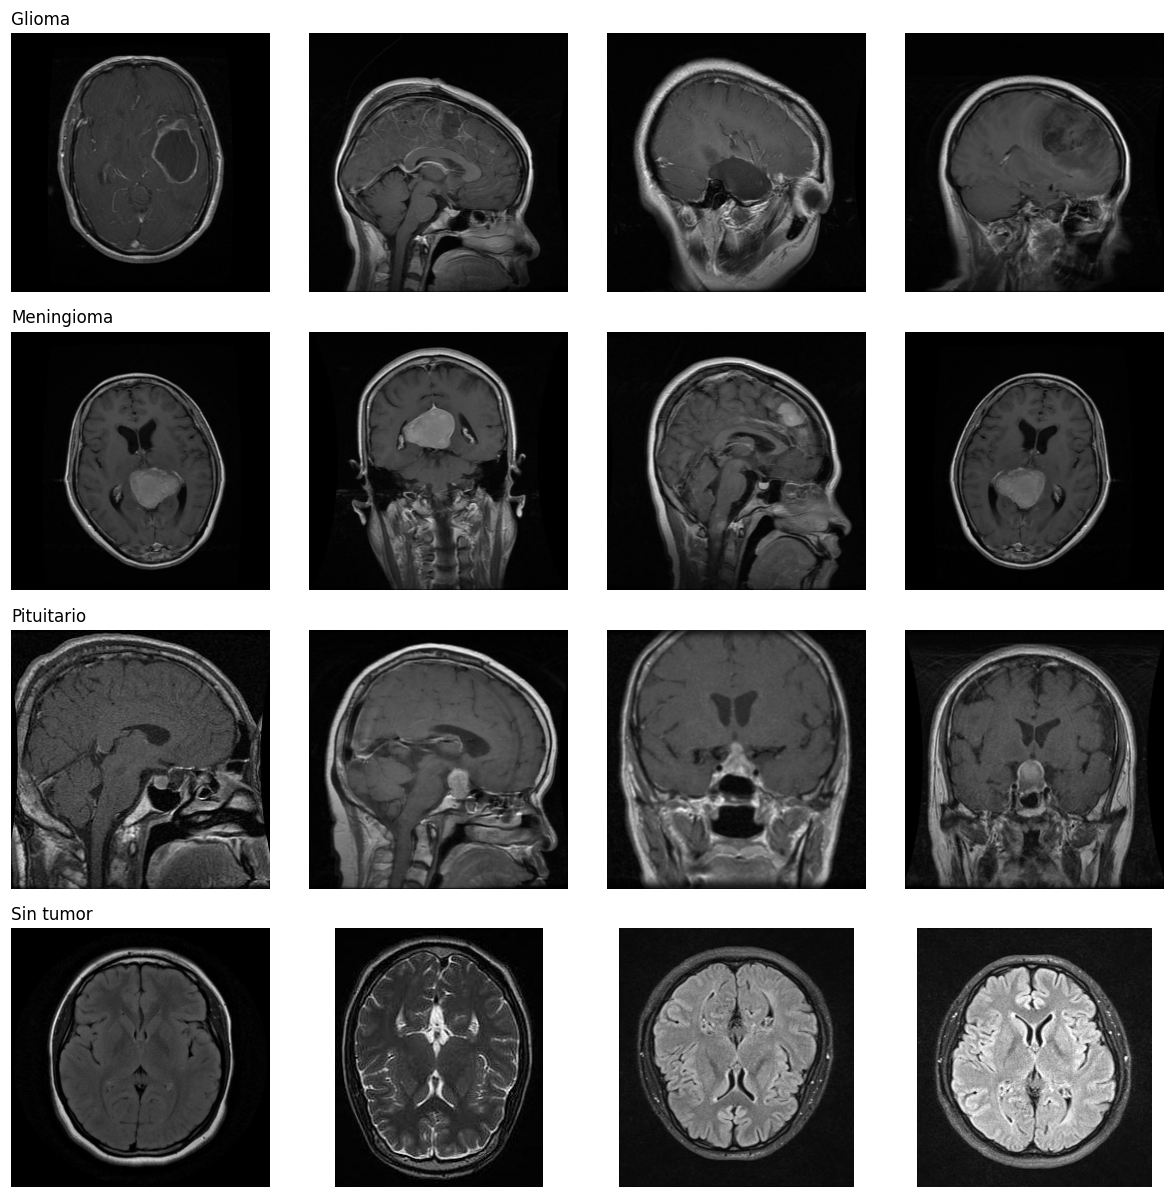

In [26]:
fig = eda.graficar_muestras(df, n_por_clase=4)
plt.show()

**Observaciones:**

- Orientación de los cortes: **mezcla de axial, sagital y coronal**, sin etiquetar y sin
  ser siquiera consistente dentro de una misma clase (ej. la fila de Glioma tiene un
  corte axial y tres sagitales). El dataset no trae metadata de orientación — ni en el
  nombre de archivo ni en un archivo aparte.
- ¿Hay texto/anotaciones quemadas en la imagen? No observo ninguna en esta muestra.
- ¿Se ve a simple vista la diferencia entre clases? Sí — Glioma muestra una masa de forma
  irregular, Meningioma un blob redondeado bien delimitado cerca de los ventrículos,
  Pituitario una lesión chica en la base del cráneo (más sutil), y "Sin tumor" se ve
  simétrico y sin masas.
- **Implicancia para el augmentation:** por la mezcla de orientaciones sin etiquetar,
  **descarto el flip horizontal** del augmentation. Es válido en cortes axiales/coronales
  (el cerebro es aprox. simétrico izquierda-derecha) pero inválido en cortes sagitales
  (invierte adelante-atrás, generando una imagen anatómicamente imposible). Sin forma
  barata de detectar la orientación por imagen sobre 7.200 imágenes, prefiero no
  arriesgarme a corromper el subconjunto sagital antes que ganar la variabilidad extra
  del flip. Rotaciones leves, zoom y brillo/contraste siguen siendo válidos en cualquier
  orientación.

---
## 5. Calidad de imagen: intensidad, contraste y fondo

Estas estadísticas sí decodifican los píxeles, así que las corro sobre una submuestra
estratificada por clase en vez de sobre las 7.200 imágenes.

Lo que busco: si alguna clase tiene un perfil de intensidad sistemáticamente distinto. Si
lo tuviera, el modelo podría estar aprendiendo el brillo de la máquina de resonancia en
vez de la patología — un atajo clásico en datasets médicos combinados de varias fuentes.

In [27]:
df_stats = eda.estadisticas_intensidad(df, muestra=400, seed=42)

print(f"Analizadas {len(df_stats)} imágenes")
df_stats.groupby("clase")[["media", "desvio", "frac_fondo", "frac_saturada"]].mean().round(3)

Analizadas 400 imágenes


,media,desvio,frac_fondo,frac_saturada
clase,,,,
glioma,34.783001,39.775002,0.510,0.002
meningioma,47.158001,47.805000,0.433,0.005
notumor,62.518002,61.734001,0.331,0.016
pituitary,49.659000,41.483002,0.302,0.000


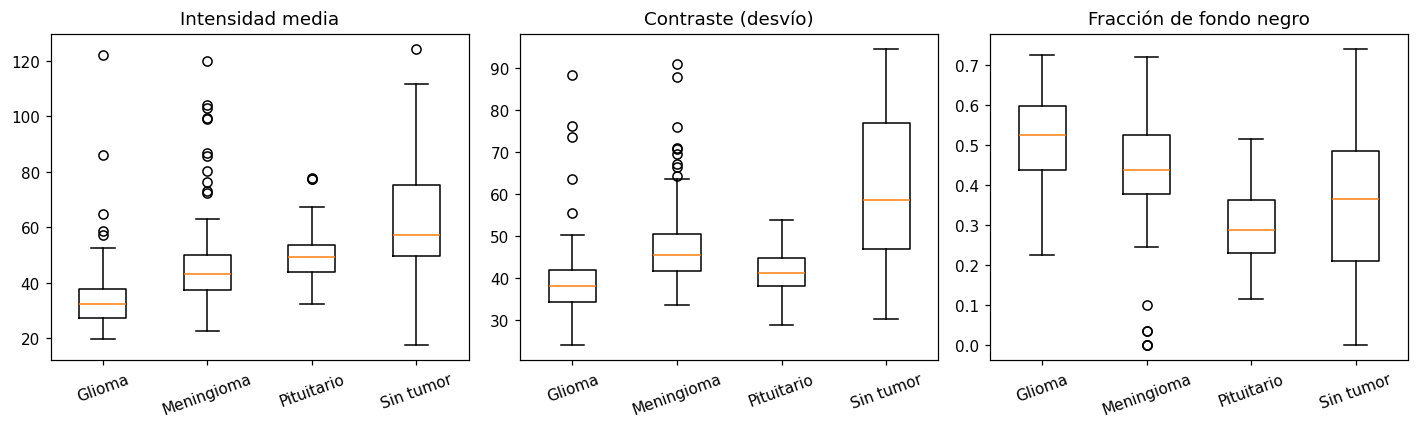

In [28]:
fig = eda.graficar_intensidades(df_stats)
plt.show()

**Conclusión:**

- ¿Los perfiles de intensidad se superponen entre clases, o alguna se separa? Se separan
  bastante: Glioma es la más oscura (media 34.8) y con más fondo negro (51%), "Sin tumor"
  la más clara (media 62.5) y con más contraste (desvío 61.7). No es ruido — hay un
  escalonamiento sistemático entre clases.
- **Hallazgo importante:** esta diferencia coincide con la composición del dataset por
  fuente, no necesariamente con una diferencia clínica. "Sin tumor" proviene 100% de
  Br35H, mientras que Glioma viene de figshare y Meningioma/Pituitario mayormente de
  SARTAJ — fuentes con protocolos de adquisición distintos. Existe riesgo real de que el
  modelo aprenda a distinguir "de qué fuente vino la imagen" en vez de patología.
- Fracción de fondo negro típica: entre 30% (Pituitario) y 51% (Glioma) en promedio, con
  bastante variabilidad → tengo margen para zoom/crop leve en el augmentation sin cortar
  el cerebro.
- ¿Hace falta normalizar por imagen, o alcanza con la normalización estándar del backbone?
  Dado el hallazgo de arriba, **no alcanza con la normalización estándar** — el
  augmentation de brillo/contraste deja de ser opcional: es mi mitigación directa contra
  el riesgo de que el modelo aprenda el "estilo" de la fuente en vez de la patología.

Lo documento también como limitación conocida en `docs/model_card.md` y
`docs/documentacion_tecnica.md`.

---
## 6. Duplicados

Este dataset es una combinación de tres fuentes (figshare + SARTAJ + Br35H), así que
puede traer la misma imagen más de una vez.

El riesgo concreto: si una imagen está duplicada y una copia cae en train mientras la
otra cae en test, las métricas de test van a estar infladas. El modelo aprueba el examen
habiendo visto las respuestas.

In [29]:
duplicados = eda.detectar_duplicados(df)

print(f"Archivos que participan de algún grupo duplicado: {len(duplicados)}")
if len(duplicados):
    print(f"Grupos distintos: {duplicados['hash'].nunique()}")
    # ¿Hay duplicados que cruzan la frontera Training/Testing original?
    cruzados = duplicados.groupby("hash")["split_origen"].nunique()
    print(f"Grupos que cruzan Training/Testing: {(cruzados > 1).sum()}")
    display(duplicados.head(10)[["archivo", "clase", "split_origen", "hash"]])
else:
    print("No hay duplicados exactos.")

Archivos que participan de algún grupo duplicado: 340
Grupos distintos: 153
Grupos que cruzan Training/Testing: 0


,archivo,clase,split_origen,hash
6408,Tr-pi_286.jpg,pituitary,training,00748c6aaa5c199b07f8fa7140fc19c1
6531,Tr-pi_397.jpg,pituitary,training,00748c6aaa5c199b07f8fa7140fc19c1
6431,Tr-pi_306.jpg,pituitary,training,008c98403b057fc344bf0a9f2e7de6c2
6279,Tr-pi_17.jpg,pituitary,training,008c98403b057fc344bf0a9f2e7de6c2
5974,Tr-pi_1155.jpg,pituitary,training,0140560cc9a91abc3e62e9e1bec6c5ea
5910,Tr-pi_1098.jpg,pituitary,training,0140560cc9a91abc3e62e9e1bec6c5ea
7071,Tr-pi_883.jpg,pituitary,training,05c3caea567ffd77caf79c12654b87e5
6569,Tr-pi_430.jpg,pituitary,training,05c3caea567ffd77caf79c12654b87e5
6337,Tr-pi_221.jpg,pituitary,training,05c3caea567ffd77caf79c12654b87e5
4838,Tr-no_1393.jpg,notumor,training,05fe39a899414d2dab6cad25c301b32c


**Conclusión:**

- Duplicados exactos encontrados: **340 archivos** (4.72% del dataset), agrupados en
  **153 grupos** de duplicados byte a byte.
- ¿Alguno cruza clases distintas? **No** — los 153 grupos son internamente consistentes
  en clase, así que no hay inconsistencia de etiquetado.
- Se concentran fuerte en "Sin tumor" (216 de 340, ~64% de los duplicados), consistente
  con que esa clase viene de una única fuente (Br35H) — otra pista de que esa clase tiene
  un origen distinto al resto (ver sección 5).
- **Ojo con mi propio split:** los 153 grupos **no cruzan la frontera Training/Testing
  original de Kaggle** (0 grupos mixtos), pero eso no me protege — voy a rehacer mi
  propio split estratificado (`preprocessing.split_dataset()`), que ignora
  `split_origen`. Sin deduplicar antes, un duplicado podría terminar con una copia en
  train y la otra en test, inflando las métricas de test.
- **Decisión:** deduplico (me quedo con una copia por grupo de hash) **antes** del split
  estratificado, dentro de `preprocessing.split_dataset()` o en un paso previo.

> Nota: esto detecta duplicados **byte a byte**. No detecta la misma imagen guardada con
> otra compresión o recortada distinto — el número real de "casi duplicados" podría ser
> más alto. Si en fase de modelado el train/test da resultados sospechosamente buenos,
> vuelvo con un hash perceptual.

---
## 7. Conclusiones del EDA

**Resumen para el tutor:**

1. **Volumen y balance:** 7.200 imágenes, perfectamente balanceadas (1.800 por clase,
   25% c/u). No necesito class weights ni sampling especial.
2. **Resolución elegida y por qué:** `image_size = 224×224`. La dominante en el dataset
   es 512×512 (70%); descarté reducir a 150 porque tira >90% de la resolución real sin
   necesidad, y elegí 224 por alinear con la resolución preentrenada estándar de
   EfficientNet-B0/MobileNetV2, aceptando upscaling leve en el 11.3% de las imágenes más
   chicas.
3. **Calidad de las imágenes:** mezcla de cortes axial/sagital/coronal sin etiquetar, y
   diferencias sistemáticas de brillo/contraste entre clases que coinciden con la
   composición del dataset por fuente (glioma=figshare, meningioma/pituitario≈SARTAJ,
   notumor=100% Br35H) más que con una diferencia clínica confirmada.
4. **Duplicados / fuga de datos:** 340 duplicados exactos (4.72%, 153 grupos, ninguno
   cruza clases), concentrados en "Sin tumor". Deduplico antes de mi propio split para no
   filtrar datos entre train y test.
5. **Implicancias para el augmentation:** descarto el flip horizontal (por la mezcla de
   orientaciones no etiquetada); el augmentation de brillo/contraste deja de ser
   opcional (mitiga el riesgo de que el modelo aprenda la fuente en vez de la patología);
   rotaciones leves y zoom siguen siendo válidos.

**Qué se destraba con esto:**

- [x] Fijar `data.image_size` en `config/config.yaml` con justificación → **224**
- [x] Definir si el entrenamiento necesita class weights → **no**
- [x] Acotar los rangos del augmentation en `src/data/augmentation.py` → sin flip
      horizontal, brillo/contraste obligatorio, rotación/zoom conservadores (pendiente de
      implementar, docstring ya actualizado)
- [x] Confirmar si hay que deduplicar antes del split estratificado → **sí**,
      documentado en el docstring de `preprocessing.split_dataset()`

**Sigue sin resolverse acá** (y no depende del EDA): PyTorch vs TensorFlow, y
EfficientNet-B0 vs MobileNetV2. Son la próxima decisión del proyecto, y bloquean
preprocesamiento, entrenamiento y evaluación.